In [40]:
"""
Post training plots; verify that the agents are actually learning
"""

import jax
import jax.numpy as jnp
import jax.random as random
import matplotlib.pyplot as plt
from matplotlib.animation import FuncAnimation
from abmax.structs import Params
from matplotlib.patches import FancyArrowPatch

import seaborn as sns
sns.set_theme(style="darkgrid")
palette = "viridis"
sns.set_palette(palette)

RENDER_DATA_PATH = "../simple_abm/data/wolf_vs_rand13/"
MAX_SPAWN_X = 500.0 # max x in spawning arena
MAX_SPAWN_Y = 500.0 # max y in spawning arena
SHEEP_RADIUS = 5.0
WOLF_RADIUS = 5.0
EP_LEN = 1500
NUM_SHEEP = 50
NUM_WOLF = 50

In [41]:
# def load_render_data(filenames):
#     return {name: jnp.load(RENDER_DATA_PATH + fname) for name, fname in filenames.items()}

file_map = {
    'sheep_xs': 'rendering_sheep_xs.npy',
    'sheep_ys': 'rendering_sheep_ys.npy',
    'sheep_angs': 'rendering_sheep_angs.npy',
    'sheep_fitness': 'rendering_sheep_fitness.npy',
    'sheep_energy': 'rendering_sheep_energy.npy',
    'wolf_xs': 'rendering_wolf_xs.npy',
    'wolf_ys': 'rendering_wolf_ys.npy',
    'wolf_angs': 'rendering_wolf_angs.npy',
    'wolf_fitness': 'rendering_wolf_fitness.npy',
    'wolf_energy': 'rendering_wolf_energy.npy'
}

In [42]:
import os

def load_render_data(filenames):
    # This maps the file on your SSD to a virtual array
    # without actually 'reading' the bits until you use them.
    return {name: jnp.load(os.path.join(RENDER_DATA_PATH, fname), mmap_mode='r')
            for name, fname in filenames.items()}

data = load_render_data(file_map)
print("Data loaded successfully!")

Data loaded successfully!


In [43]:
print(*(f"{k}: {v.shape}" for k, v in data.items()))

sheep_xs: (1, 16, 1500, 50, 1) sheep_ys: (1, 16, 1500, 50, 1) sheep_angs: (1, 16, 1500, 50, 1) sheep_fitness: (1, 16, 1500, 50, 1) sheep_energy: (1, 16, 1500, 50, 1) wolf_xs: (1, 16, 1500, 50, 1) wolf_ys: (1, 16, 1500, 50, 1) wolf_angs: (1, 16, 1500, 50, 1) wolf_fitness: (1, 16, 1500, 50, 1) wolf_energy: (1, 16, 1500, 50, 1)


In [44]:
def select_episode(data, env_idx, ep_idx):
    """Select a single environment and episode from the full dataset."""
    sheep_xs = jnp.squeeze(data['sheep_xs'][env_idx, ep_idx])
    sheep_ys = jnp.squeeze(data['sheep_ys'][env_idx, ep_idx])
    sheep_angs = jnp.squeeze(data['sheep_angs'][env_idx, ep_idx])
    sheep_fitness = jnp.squeeze(data['sheep_fitness'][env_idx, ep_idx])
    sheep_energy = data['sheep_energy'][env_idx, ep_idx]

    wolf_xs = jnp.squeeze(data['wolf_xs'][env_idx, ep_idx])
    wolf_ys = jnp.squeeze(data['wolf_ys'][env_idx, ep_idx])
    wolf_angs = jnp.squeeze(data['wolf_angs'][env_idx, ep_idx])
    wolf_fitness = jnp.squeeze(data['wolf_fitness'][env_idx, ep_idx])
    wolf_energy = data['wolf_energy'][env_idx, ep_idx]

    return {
        'sheep_xs': sheep_xs,
        'sheep_ys': sheep_ys,
        'sheep_angs': sheep_angs,
        'sheep_fitness': sheep_fitness,
        'sheep_energy': sheep_energy,
        'wolf_xs': wolf_xs,
        'wolf_ys': wolf_ys,
        'wolf_angs': wolf_angs,
        'wolf_fitness': wolf_fitness,
        'wolf_energy': wolf_energy
    }
env_idx, ep_idx = 0, 0
# generation, world
episode_data = select_episode(data, env_idx, ep_idx)

print(*(f"{k}: {v.shape}" for k, v in episode_data.items()))

sheep_xs: (1500, 50) sheep_ys: (1500, 50) sheep_angs: (1500, 50) sheep_fitness: (1500, 50) sheep_energy: (1500, 50, 1) wolf_xs: (1500, 50) wolf_ys: (1500, 50) wolf_angs: (1500, 50) wolf_fitness: (1500, 50) wolf_energy: (1500, 50, 1)


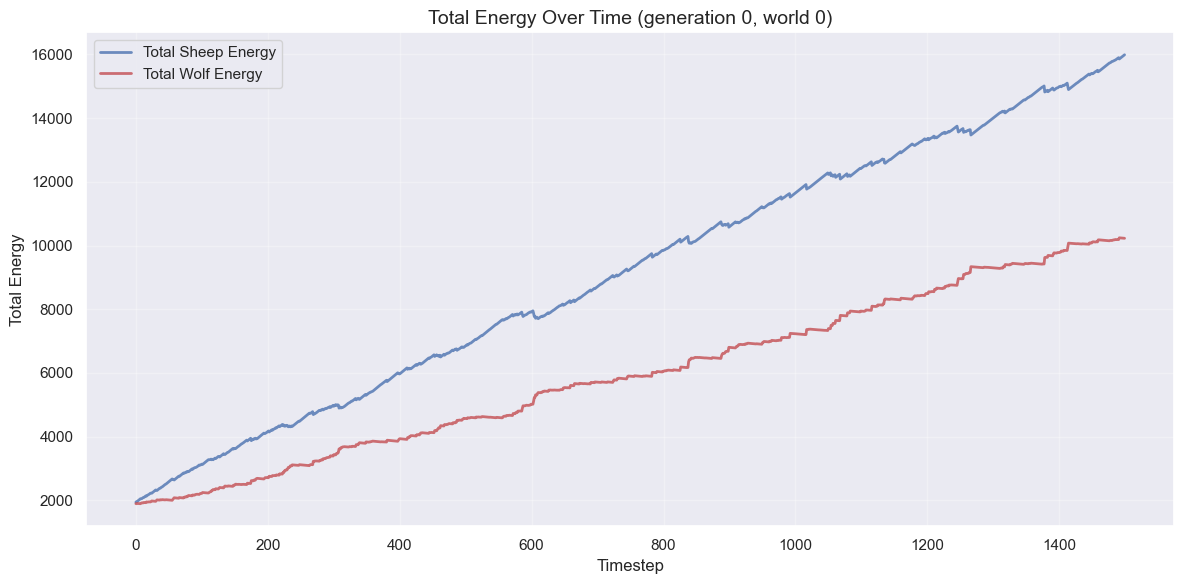

Sheep Energy - Start: 1942.13, End: 15988.68, Change: 14046.55
Wolf Energy - Start: 1894.86, End: 10226.86, Change: 8332.00


In [45]:
"""
The function plot_total_fitness takes data from a single generation and world and plots the sum of agent fitness at every timestep. It shows how the total energy of the sheep and wolves fluctuates during that one specific generation.
"""

def plot_total_energy(episode_data):
    """Plot total energy (sum across all individuals) for sheep and wolves over time."""
    # calculate total energy for each species at each timestep
    total_sheep_energy = jnp.sum(episode_data['sheep_energy'], axis=1)  # sum over all sheep
    total_wolf_energy = jnp.sum(episode_data['wolf_energy'], axis=1)    # sum over all wolves

    ts = jnp.arange(EP_LEN)

    fig, ax = plt.subplots(figsize=(12, 6))

    ax.plot(ts, total_sheep_energy, label='Total Sheep Energy', linewidth=2, alpha=0.8, color='b')
    ax.plot(ts, total_wolf_energy, label='Total Wolf Energy', linewidth=2, alpha=0.8, color='r')

    ax.set_xlabel('Timestep', fontsize=12)
    ax.set_ylabel('Total Energy', fontsize=12)
    ax.set_title(f'Total Energy Over Time (generation {env_idx}, world {ep_idx})', fontsize=14)
    ax.legend(fontsize=11)
    ax.grid(True, alpha=0.3)

    plt.tight_layout()
    plt.show()

    print(f"Sheep Energy - Start: {total_sheep_energy[0].item():.2f}, "
          f"End: {total_sheep_energy[-1].item():.2f}, "
          f"Change: {(total_sheep_energy[-1] - total_sheep_energy[0]).item():.2f}")

    print(f"Wolf Energy - Start: {total_wolf_energy[0].item():.2f}, "
          f"End: {total_wolf_energy[-1].item():.2f}, "
          f"Change: {(total_wolf_energy[-1] - total_wolf_energy[0]).item():.2f}")


plot_total_energy(episode_data)

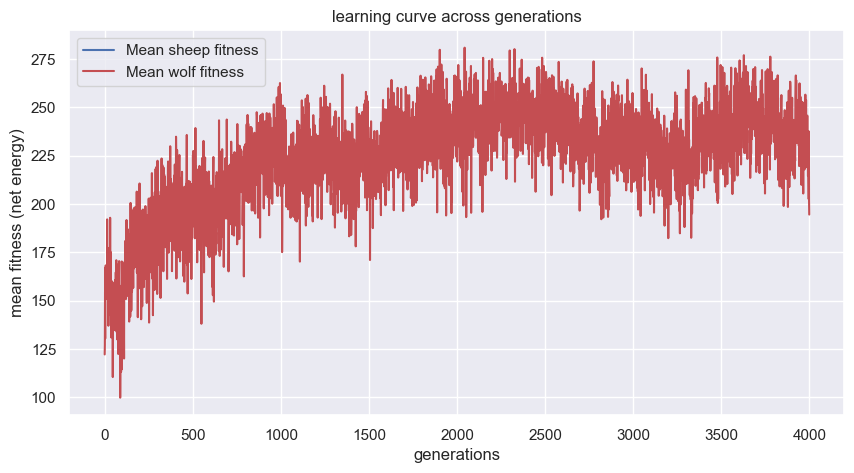

In [46]:
"""
Training process; verify if agents are learning correctly
--> the fitness values should generally increase over the generations
"""

# Load the generational progress data
sheep_gen_fitness = jnp.load(RENDER_DATA_PATH + 'mean_sheep_fitness_list.npy')
wolf_gen_fitness = jnp.load(RENDER_DATA_PATH + 'mean_wolf_fitness_list.npy')

# Plotting the learning curve
plt.figure(figsize=(10, 5))
plt.plot(sheep_gen_fitness, label="Mean sheep fitness", color='b')
plt.plot(wolf_gen_fitness, label="Mean wolf fitness", color='r')
plt.xlabel("generations")
plt.ylabel("mean fitness (net energy)")
plt.title("learning curve across generations")
plt.legend()
plt.show()